#### *Se cargan los tres datasets y se muestran las primeras filas*

In [28]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import seaborn as sns

In [19]:
import pandas as pd

# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())



### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589


In [20]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")

### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-null  object
 4   Costo_Mantenimiento  31866 non-null  int64 
 5   Duracion_Horas       31866 non-null  int64 
 6   Ubicacion            31866 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

#### *Este código realiza una serie de transformaciones sobre un archivo (Historicos_Ordenes.csv) para añadir una nueva columna que indica cuántos mantenimientos correctivos ha tenido cada equipo en ventanas de 2 semanas (ordenes_df).*

In [3]:
import pandas as pd

# Cargar el archivo Historicos_Ordenes.csv
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")

# Renombrar la columna 'Fecha' por 'Fecha_ot'
ordenes_df.rename(columns={"Fecha": "Fecha_ot"}, inplace=True)

# Asegurarse de que 'Fecha_ot' sea de tipo datetime
ordenes_df['Fecha_ot'] = pd.to_datetime(ordenes_df['Fecha_ot'])

# Filtrar solo los registros de mantenimiento correctivo (hacer una copia para evitar SettingWithCopyWarning)
correctivos_df = ordenes_df[ordenes_df['Tipo_Mantenimiento'].str.lower() == 'correctivo'].copy()

# Crear columna de ventana de 2 semanas para agrupar
correctivos_df['Periodo'] = correctivos_df['Fecha_ot'].dt.to_period('2W').dt.start_time

# Contar correctivos por ID_Equipo y Periodo
frecuencia = correctivos_df.groupby(['ID_Equipo', 'Periodo']).size().reset_index(name='frecuencia_correctivo')

# Crear la columna 'Periodo' en el DataFrame original
ordenes_df['Periodo'] = ordenes_df['Fecha_ot'].dt.to_period('2W').dt.start_time

# Unir la frecuencia al dataframe original
ordenes_df = ordenes_df.merge(frecuencia, on=['ID_Equipo', 'Periodo'], how='left')

# Rellenar los NaN con 0 y convertir a int de forma segura (sin inplace)
ordenes_df['frecuencia_correctivo'] = ordenes_df['frecuencia_correctivo'].fillna(0).astype(int)

# Mostrar dataframe

ordenes_df.head(500)

,ID_Orden,ID_Equipo,Fecha_ot,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Periodo,frecuencia_correctivo
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A,2020-12-28,1
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A,2020-12-28,1
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B,2020-12-28,1
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D,2020-12-28,1
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B,2020-12-28,1
...,...,...,...,...,...,...,...,...,...
495,496,86,2021-02-02,Preventivo,745,1,Ubicacion_A,2021-02-01,0
496,497,143,2021-02-02,Preventivo,672,1,Ubicacion_A,2021-02-01,0
497,498,437,2021-02-02,Preventivo,409,1,Ubicacion_A,2021-02-01,0
498,499,431,2021-02-02,Preventivo,495,2,Ubicacion_D,2021-02-01,0


In [4]:
# Asegúrate de tener ambas tablas cargadas
# ordenes_df ya procesado con frecuencia_correctivo
# caracteristicas_df cargado desde Caracteristicas_Equipos.csv

# Hacer el merge por ID_Equipo
ordenes_enriquecido = pd.merge(
    ordenes_df,
    caracteristicas_df,
    on='ID_Equipo',
    how='left'  # si quieres mantener todas las órdenes, aunque no haya características
)

# Verificar resultado
ordenes_enriquecido.head(10)

,ID_Orden,ID_Equipo,Fecha_ot,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Periodo,frecuencia_correctivo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A,2020-12-28,1,Bomba,Fabricante_A,Modelo_10,281,634
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A,2020-12-28,1,Generador,Fabricante_A,Modelo_9,127,608
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B,2020-12-28,1,Generador,Fabricante_C,Modelo_9,331,701
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D,2020-12-28,1,Compresor,Fabricante_B,Modelo_9,71,660
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B,2020-12-28,1,Compresor,Fabricante_D,Modelo_3,281,750
5,6,430,2021-01-02,Correctivo,1165,8,Ubicacion_D,2020-12-28,1,Motor,Fabricante_B,Modelo_8,54,828
6,7,334,2021-01-02,Correctivo,538,18,Ubicacion_C,2020-12-28,1,Bomba,Fabricante_B,Modelo_10,381,609
7,8,53,2021-01-02,Correctivo,1172,23,Ubicacion_D,2020-12-28,1,Generador,Fabricante_A,Modelo_2,57,596
8,9,84,2021-01-02,Correctivo,1461,7,Ubicacion_C,2020-12-28,1,Bomba,Fabricante_C,Modelo_7,462,653
9,10,75,2021-01-02,Correctivo,1390,23,Ubicacion_D,2020-12-28,1,Compresor,Fabricante_C,Modelo_3,255,861


In [5]:
ordenes_enriquecido.to_csv("../src/ordenes_con_caracteristicas.csv", index=False)

In [6]:
ordenes_enriquecido.head(500)

,ID_Orden,ID_Equipo,Fecha_ot,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Periodo,frecuencia_correctivo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A,2020-12-28,1,Bomba,Fabricante_A,Modelo_10,281,634
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A,2020-12-28,1,Generador,Fabricante_A,Modelo_9,127,608
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B,2020-12-28,1,Generador,Fabricante_C,Modelo_9,331,701
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D,2020-12-28,1,Compresor,Fabricante_B,Modelo_9,71,660
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B,2020-12-28,1,Compresor,Fabricante_D,Modelo_3,281,750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,86,2021-02-02,Preventivo,745,1,Ubicacion_A,2021-02-01,0,Compresor,Fabricante_D,Modelo_7,180,725
496,497,143,2021-02-02,Preventivo,672,1,Ubicacion_A,2021-02-01,0,Compresor,Fabricante_C,Modelo_2,494,891
497,498,437,2021-02-02,Preventivo,409,1,Ubicacion_A,2021-02-01,0,Compresor,Fabricante_C,Modelo_8,405,711
498,499,431,2021-02-02,Preventivo,495,2,Ubicacion_D,2021-02-01,0,Bomba,Fabricante_C,Modelo_10,169,717


In [26]:
# Evitar división por cero
ordenes_enriquecido['ratio_mantenimiento_recomendado'] = (
    ordenes_enriquecido['Duracion_Horas'] / ordenes_enriquecido['Horas_Recomendadas_Revision']
).replace([np.inf, -np.inf], np.nan)

ordenes_enriquecido['costo_por_hora'] = (
    ordenes_enriquecido['Costo_Mantenimiento'] / ordenes_enriquecido['Duracion_Horas']
).replace([np.inf, -np.inf], np.nan)

In [36]:
# Asegurarse de que Fecha_ot esté en datetime
ordenes_enriquecido['Fecha_ot'] = pd.to_datetime(ordenes_enriquecido['Fecha_ot'])

# -----------------------
# 4. Mantenimientos anuales
# -----------------------
ordenes_enriquecido['anio'] = ordenes_enriquecido['Fecha_ot'].dt.year

ordenes_enriquecido['mantenimientos_anuales'] = (
    ordenes_enriquecido
    .groupby(['ID_Equipo', 'anio'])['ID_Orden']
    .transform('count')
)

# -----------------------
# 5. Días desde el último mantenimiento
# -----------------------
ordenes_enriquecido = ordenes_enriquecido.sort_values(['ID_Equipo', 'Fecha_ot'])

ordenes_enriquecido['dias_desde_ultimo_mant'] = (
    ordenes_enriquecido
    .groupby('ID_Equipo')['Fecha_ot']
    .diff()
    .dt.days
)

# Calcular la media, ignorando los NaN
media_dias = ordenes_enriquecido['dias_desde_ultimo_mant'].mean()

# Rellenar los NaN con la media
ordenes_enriquecido['dias_desde_ultimo_mant'] = ordenes_enriquecido['dias_desde_ultimo_mant'].fillna(media_dias)

# Codificar
ordenes_enriquecido['Tipo_Mantenimiento_cod'] = ordenes_enriquecido['Tipo_Mantenimiento'].map({
    'Preventivo': 0,
    'Correctivo': 1
})

# Rellenar NaN con 0
ordenes_enriquecido['Tipo_Mantenimiento_cod'] = ordenes_enriquecido['Tipo_Mantenimiento_cod'].fillna(0).astype(int)


In [39]:
ordenes_enriquecido.head(500)

,ID_Orden,ID_Equipo,Fecha_ot,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Periodo,frecuencia_correctivo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ratio_mantenimiento_recomendado,costo_por_hora,anio,mantenimientos_anuales,dias_desde_ultimo_mant,Tipo_Mantenimiento_cod
390,391,1,2021-01-30,Preventivo,964,2,Ubicacion_A,2021-01-25,0,Bomba,Fabricante_A,Modelo_8,432,657,0.003044,482.000,2021,16,22.647357,0
1016,1017,1,2021-03-01,Preventivo,981,1,Ubicacion_A,2021-03-01,0,Bomba,Fabricante_A,Modelo_8,432,657,0.001522,981.000,2021,16,30.000000,0
1544,1545,1,2021-03-24,Preventivo,222,1,Ubicacion_A,2021-03-22,0,Bomba,Fabricante_A,Modelo_8,432,657,0.001522,222.000,2021,16,23.000000,0
1993,1994,1,2021-04-15,Preventivo,327,2,Ubicacion_A,2021-04-12,0,Bomba,Fabricante_A,Modelo_8,432,657,0.003044,163.500,2021,16,22.000000,0
2689,2690,1,2021-05-16,Preventivo,310,2,Ubicacion_A,2021-05-10,0,Bomba,Fabricante_A,Modelo_8,432,657,0.003044,155.000,2021,16,31.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10480,10481,9,2022-05-05,Preventivo,923,1,Ubicacion_C,2022-05-02,0,Generador,Fabricante_D,Modelo_8,351,569,0.001757,923.000,2022,22,25.000000,0
11067,11068,9,2022-05-31,Preventivo,158,2,Ubicacion_C,2022-05-30,0,Generador,Fabricante_D,Modelo_8,351,569,0.003515,79.000,2022,22,26.000000,0
11642,11643,9,2022-06-26,Preventivo,271,2,Ubicacion_C,2022-06-20,0,Generador,Fabricante_D,Modelo_8,351,569,0.003515,135.500,2022,22,26.000000,0
12168,12169,9,2022-07-20,Preventivo,485,2,Ubicacion_C,2022-07-18,1,Generador,Fabricante_D,Modelo_8,351,569,0.003515,242.500,2022,22,24.000000,0


#### *Este código realiza una serie de transformaciones sobre un archivo (Registros_Condiciones.csv) para añadir una nueva columna que indica cuántas anomalías ha tenido cada equipo en ventanas de 2 semanas (condiciones_df).*

In [7]:
import pandas as pd

# Cargar datos
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Renombrar la columna 'Fecha' a 'Fecha_anomalia'
condiciones_df.rename(columns={'Fecha': 'Fecha_anomalia'}, inplace=True)

# Asegurarse que 'Fecha_anomalia' sea tipo datetime
condiciones_df['Fecha_anomalia'] = pd.to_datetime(condiciones_df['Fecha_anomalia'])

# Crear columna de periodo de 2 semanas
condiciones_df['Periodo'] = condiciones_df['Fecha_anomalia'].dt.to_period('2W').dt.start_time

# Contar número de anomalías por ID_Equipo y Periodo
frecuencia_anomalias = (
    condiciones_df.groupby(['ID_Equipo', 'Periodo'])
    .size()
    .reset_index(name='frecuencia_anomalia')
)

# Unir esa frecuencia al DataFrame original
condiciones_df = condiciones_df.merge(frecuencia_anomalias, on=['ID_Equipo', 'Periodo'], how='left')

# Mostrar resultado
condiciones_df.head(500)


,ID_Registro,ID_Equipo,Fecha_anomalia,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Periodo,frecuencia_anomalia
0,1,1,2021-01-01,36.587104,4.430381,579,2020-12-28,3
1,2,106,2021-01-01,53.268051,0.534711,577,2020-12-28,3
2,3,446,2021-01-01,47.176472,7.116958,263,2020-12-28,3
3,4,107,2021-01-01,76.404597,2.696906,491,2020-12-28,3
4,5,108,2021-01-01,50.729327,6.996772,589,2020-12-28,3
...,...,...,...,...,...,...,...,...
495,496,384,2021-01-01,65.057930,8.697510,171,2020-12-28,3
496,497,226,2021-01-01,87.706190,8.178038,511,2020-12-28,3
497,498,388,2021-01-01,59.433401,7.663646,69,2020-12-28,3
498,499,2,2021-01-01,90.809284,7.934667,708,2020-12-28,3


In [8]:
# Hacer merge de condiciones con características técnicas
condiciones_enriquecido = pd.merge(
    condiciones_df,
    caracteristicas_df,
    on='ID_Equipo',
    how='left'  # conserva todos los registros de condiciones
)

# Ver una muestra del resultado
condiciones_enriquecido.head(500)

,ID_Registro,ID_Equipo,Fecha_anomalia,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Periodo,frecuencia_anomalia,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,1,2021-01-01,36.587104,4.430381,579,2020-12-28,3,Bomba,Fabricante_A,Modelo_8,432,657
1,2,106,2021-01-01,53.268051,0.534711,577,2020-12-28,3,Motor,Fabricante_D,Modelo_3,448,801
2,3,446,2021-01-01,47.176472,7.116958,263,2020-12-28,3,Generador,Fabricante_C,Modelo_2,95,561
3,4,107,2021-01-01,76.404597,2.696906,491,2020-12-28,3,Compresor,Fabricante_A,Modelo_7,195,748
4,5,108,2021-01-01,50.729327,6.996772,589,2020-12-28,3,Compresor,Fabricante_A,Modelo_9,181,560
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,384,2021-01-01,65.057930,8.697510,171,2020-12-28,3,Motor,Fabricante_A,Modelo_1,208,773
496,497,226,2021-01-01,87.706190,8.178038,511,2020-12-28,3,Compresor,Fabricante_C,Modelo_10,436,672
497,498,388,2021-01-01,59.433401,7.663646,69,2020-12-28,3,Motor,Fabricante_C,Modelo_6,474,543
498,499,2,2021-01-01,90.809284,7.934667,708,2020-12-28,3,Generador,Fabricante_B,Modelo_2,393,522


In [9]:
# Calcular la diferencia entre horas operativas reales y las recomendadas
condiciones_enriquecido['exceso_horas_operativas'] = (
    condiciones_enriquecido['Horas_Recomendadas_Revision'] - condiciones_enriquecido['Horas_Operativas']
)

In [10]:
# Ver una muestra del resultado
condiciones_enriquecido.head(500)

,ID_Registro,ID_Equipo,Fecha_anomalia,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Periodo,frecuencia_anomalia,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,exceso_horas_operativas
0,1,1,2021-01-01,36.587104,4.430381,579,2020-12-28,3,Bomba,Fabricante_A,Modelo_8,432,657,78
1,2,106,2021-01-01,53.268051,0.534711,577,2020-12-28,3,Motor,Fabricante_D,Modelo_3,448,801,224
2,3,446,2021-01-01,47.176472,7.116958,263,2020-12-28,3,Generador,Fabricante_C,Modelo_2,95,561,298
3,4,107,2021-01-01,76.404597,2.696906,491,2020-12-28,3,Compresor,Fabricante_A,Modelo_7,195,748,257
4,5,108,2021-01-01,50.729327,6.996772,589,2020-12-28,3,Compresor,Fabricante_A,Modelo_9,181,560,-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,384,2021-01-01,65.057930,8.697510,171,2020-12-28,3,Motor,Fabricante_A,Modelo_1,208,773,602
496,497,226,2021-01-01,87.706190,8.178038,511,2020-12-28,3,Compresor,Fabricante_C,Modelo_10,436,672,161
497,498,388,2021-01-01,59.433401,7.663646,69,2020-12-28,3,Motor,Fabricante_C,Modelo_6,474,543,474
498,499,2,2021-01-01,90.809284,7.934667,708,2020-12-28,3,Generador,Fabricante_B,Modelo_2,393,522,-186


In [11]:
condiciones_enriquecido.to_csv("../src/condiciones_con_caracteristicas.csv", index=False)

#### *1. IMPORTANCIA DE CARACTERÍSTICAS: ordenes_enriquecido* 

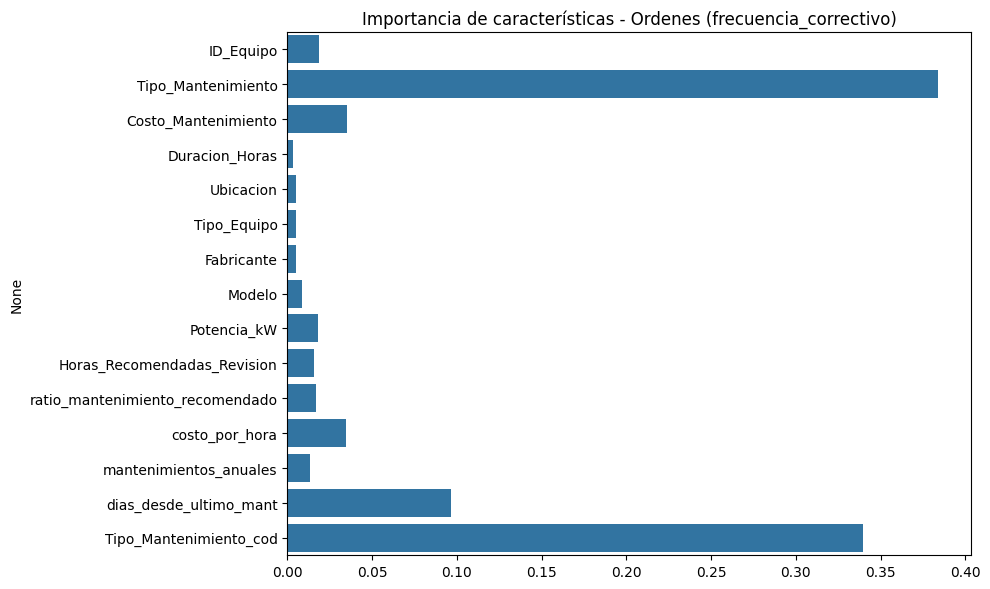

In [42]:
# Copiar y limpiar
df = ordenes_enriquecido.copy().dropna()
X = df.drop(columns=['frecuencia_correctivo' , 'Fecha_ot', 'Periodo', 'ID_Orden','anio'], errors='ignore')
y = df['frecuencia_correctivo']

# Codificar categorías
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Train/Test y modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Visualización
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Importancia de características - Ordenes (frecuencia_correctivo)")
plt.tight_layout()
plt.show()


#### *2. IMPORTANCIA DE CARACTERÍSTICAS: condiciones_enriquecido*

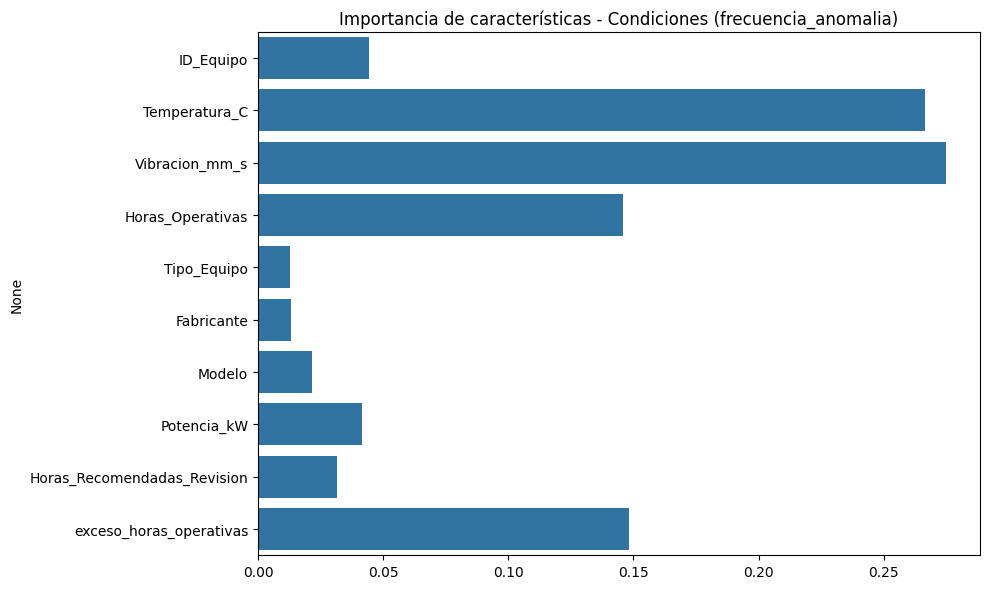

In [15]:
# Copiar y limpiar
df = condiciones_enriquecido.copy().dropna()
X = df.drop(columns=['ID_Registro', 'frecuencia_anomalia', 'Fecha_anomalia', 'Periodo'], errors='ignore')
y = df['frecuencia_anomalia']

# Codificar categorías
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Train/Test y modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Visualización
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Importancia de características - Condiciones (frecuencia_anomalia)")
plt.tight_layout()
plt.show()
